EDA draft

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
DATA_FOLDER: str = "./data/"
UNICEF_DATA_CSV: str = DATA_FOLDER + "unicef_malawi.csv"
OUTPUT_FOLDER: str = "./output/"

# Rank correlations to target
We use Cramér's V to measure the association between each feature and the target, removing features with Cramér's V < 0.05, corresponding to less than 0.25% of variance explained individually. While individual features explain modest variance; reflecting the multifactorial and self-reported nature of the data, the combined predictive power of retained features is expected to be substantially higher, as the model learns from many weak signals jointly.

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

def perform_cramers_v(
    *,
    df: pd.DataFrame,
    min_score: float = 0.05,
    target_column_name: str,
    ignore_columns: list,
) -> pd.DataFrame:
    """Performs cramers v test on the columns in the provided 'df' 
    against the 'target_column_name' column and returns a pd.DataFrame
    containing the signficiant features that meet the 'min_score'
    threshold. Ignores the 'ignore_columns'.
    """
    results = []
    df_without_target = df.drop(columns=ignore_columns)
    for col in df_without_target.columns:
        contingency_table = pd.crosstab(df[col], df[target_column_name])
        chi2, p, _, _ = chi2_contingency(contingency_table)
        n = contingency_table.sum().sum()
        min_dim = min(contingency_table.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim))
        results.append({"feature_name": col, "p_value": p, "cramers_v": cramers_v})
    results_df = pd.DataFrame(results).sort_values("cramers_v", ascending=False)
    return results_df[results_df["cramers_v"] > min_score]

We remove w-score from our feature set as it represents a measure of child happiness; arguably an alternative target variable rather than a predictor, and its inclusion would risk circular reasoning. We additionally remove ethnicity to prevent the introduction of racial bias into a model that will inform resource allocation decisions. While ethnicity shows a weak but non-negligible association with depression (Cramér's V = 0.1, accounting for ~1% of variance), this association likely reflects proxy effects of socioeconomic status, cultural differences in self-reporting, or experiences of discrimination; factors better captured by other features in the dataset. We note that any future reintroduction of ethnicity would require significant ethical justification. This leaves us with 27 features.

In [ ]:
def remove_features_from_df(
    *,
    df: pd.DataFrame,
    features_to_remove: list[str],
) -> pd.DataFrame:
    """Removes the features in 'features_to_remove' from the provided 'df' and returns the df.
    """
    return df[~df["feature_name"].isin(features_to_remove)] # removes features not in features_to_remove.

We now need to transform categories of features into numerical representations, either one-hot encodings, binary, or ordinal.

# Full Pipeline

In [ ]:
class FeatureNames:
    """Stores feature names used throughout.
    Does not containt all 87 features in the dataset.
    """
    CL3 = "CL3"
    CL13 = "CL13"
    FCD2H = "FCD2H"
    FCD2H_ANSWERED = "FCD2H_ANSWERED"
    FCD2J = "FCD2J"
    FCD2J_ANSWERED = "FCD2J_ANSWERED"
    LS1 = "LS1"
    LS2 = "LS2"
    LS3 = "LS3"
    LS4 = "LS4"
    FCF26 = "FCF26"
    FCF26_BINARY = "FCF26_binary"
    ETHNICITY = "ethnicity"
    WSCORE = "wscore"
    HH7 = "HH7"
    HC4 = "HC4"
    HC4_AGGREGATED = "HC4_AGGREGATED"
    HC5 = "HC5"
    HC5_AGGREGATED = "HC5_AGGREGATED"
    HC8 = "HC8"
    HC12 = "HC12"
    MA2 = "MA2"
    MA2_KNOWN = "MA2_KNOWN"
    MSTATUS = "MSTATUS"
    VT20 = "VT20"
    VT22A = "VT22A"
    VT22B = "VT22B"
    VT22C = "VT22C"
    VT22D = "VT22D"
    WS11 = "WS11"
    WS1 = "WS1"
    WS1_AGGREGATED = "WS1_AGGREGATED"
    WS4 = "WS4"
    WS7 = "WS7"

"""
====================
 feature_config map
====================
feature_config contains a map of feature name mapped to a dictionary of rules
as to how the feature will be transformed. "map" is used to map non-numeric
values to numeric ones. "numeric": True means the feature's values will be
coerced into numbers; i.e "30" will become 30.
"""
feature_config = {
    # LS1: To Mother: mother's happiness level, 4 categories
    FeatureNames.LS1: {
        "map": {
            "VERY UNHAPPY": 0,
            "SOMEWHAT UNHAPPY": 1,
            "NEITHER HAPPY NOR UNHAPPY": 2,
            "SOMEWHAT HAPPY": 3,
            "VERY HAPPY": 4,
            "NO RESPONSE": -1,
        },
    },
    # LS2 To Mother: mother's happiness level 0-10
    FeatureNames.LS2: {
        "map": {
            "NO RESPONSE": None,
        },
        "numeric": True,
    },
    # LS3: To Mother: Compared to this time last year, would you say that your
    #      life has improved, stayed more or less the same, or worsened,
    #      overall?
    FeatureNames.LS3: {
        "map": {
            "WORSENED": 0,
            "MORE OR LESS THE SAME": 1,
            "IMPROVED": 2,
            "NO RESPONSE": -1,
        },
    },
    # LS4: To Mother: And in one year from now, do you expect that your life
    #      will be better, will be more or less the same, or will be worse,
    #      overall?
    FeatureNames.LS4: {
        "map": {
            "WORSE": 0,
            "MORE OR LESS THE SAME": 1,
            "BETTER": 2,
            "NO RESPONSE": -1,
        },
    },
    # WS4: How long does it take for members of your household to go there,
    #      get water, and come back?
    #      "NO RESPONSE" implies they do not collect water and it is readily
    #      available, as WS4 question is only asked for certain water types
    #      involving travel.
    FeatureNames.WS4: {
        "map": {"DK": None, "MEMBERS DO NOT COLLECT": 0, "NO RESPONSE": 0, np.nan: 0}, "numeric": True,
    },
    # WS7: In the last month, has there been any time when your household did
    #      not have sufficient quantities of drinking water?
    FeatureNames.WS7: {
        "map": {
            "NO, ALWAYS SUFFICIENT": 0,
            "YES, AT LEAST ONCE": 1,
            "DK": -1,
            "NO RESPONSE": -1,
        },
    },
    # VT20: To Mother: How safe do you feel walking alone in your neighbourhood
    #       after dark?
    FeatureNames.VT20: {
        "map": {
            "VERY UNSAFE": 0,
            "UNSAFE": 1,
            "NEVER WALK ALONE AFTER DARK": 2,
            "SAFE": 3,
            "VERY SAFE": 4,
            "NO RESPONSE": -1,
        },
    },
    # VT22: In the past 12 months, have you personally felt discriminated
    #       against or harassed on the basis of the following grounds?
    # VT22A: A) Ethnic or immigration origin?
    FeatureNames.VT22A: {"map": {"NO": 0, "YES": 1, "DK": -1, "NO RESPONSE": -1}},
    # VT22B: B) Sex?
    FeatureNames.VT22B: {"map": {"NO": 0, "YES": 1, "DK": -1, "NO RESPONSE": -1}},
    # VT22C: C) Sexual orientation?
    FeatureNames.VT22C: {"map": {"NO": 0, "YES": 1, "DK": -1, "NO RESPONSE": -1}},
    # VT22D: D) Age?
    FeatureNames.VT22D: {"map": {"NO": 0, "YES": 1, "DK": -1, "NO RESPONSE": -1}},
    # MA2: How old is your (husband/partner)?
    # -1 represents information not known, we'll later create a binary feature
    # indicating whether husband/partner's age is known in the dataset or not.
    FeatureNames.MA2: {"map": {"DK": -1, "NO RESPONSE": -1, np.nan: -1}, "numeric": True},
    # CL3: Since last (day of the week) about how many hours did (name) engage
    #      in (this activity/these activities), in total?
    #      Map np.nan values to 0 because if all answers to question CL2 are no,
    #      then question CL3 is skipped, implying 0 child labour hours worked.
    FeatureNames.CL3: {"map": {np.nan: 0}, "numeric": True},
    # CL13: Since last (day of the week), about how many hours did (name)
    #       engage in (this activity/these activities), in total?
    #       Again map np.nan values to 0. If all answers to question CL2 are
    #       no then question CL13 is skipped. There are 2 "NO RESPONSE" values.
    #       We map them to 0. Alternatively we could drop the two rows
    #       corresponding to "NO RESPONSE".
    FeatureNames.CL13: {
        "map": {
            "NO RESPONSE": 0,
            np.nan: 0
        },
        "numeric": True
    },
    # HC12: Does any member of your household have a mobile telephone?
    FeatureNames.HC12: {"map": {"NO": 0, "YES": 1, "NO RESPONSE": -1}},
    # MSTATUS: marital status of mother
    FeatureNames.MSTATUS: {
        "map": {
            "Never married/in union": 0,
            "Formerly married/in union": 1,
            "Currently married/in union": 2,
        },
    },
    #FCD: Question to child: Adults use certain ways to teach children the 
    # right behaviour or to address a behaviour problem. I will read various
    # methods that are used. Please tell me if you or any other adult in your
    # household has used this method with (name) in the past month.

    # FCD2H: Called (him/her) dumb, lazy or another name like that.
    #        We set "NO RESPONSE": -1, later we will introduce a new binary
    #        feature that indentifies whether the question was answered or not.
    FeatureNames.FCD2H: {"map": {"NO": 0, "YES": 1, "NO RESPONSE": -1, np.nan: -1}},
    # FCD2J: Hit or slapped (him/her) on the hand, arm, or leg.
    #        Ditto: We set "NO RESPONSE": -1, and later introduce binary feature
    #        identifying whether question was answered.
    FeatureNames.FCD2J: {"map": {"NO": 0, "YES": 1, "NO RESPONSE": -1, np.nan: -1}},
    # HC8: Does your household have electricity?
    FeatureNames.HC8: {
        "map": {
            "NO": 0,
            "YES, OFF-GRID (GENERATOR/ISOLATED SYSTEM)": 1,
            "YES, INTERCONNECTED GRID": 2,
            "NO RESPONSE": -1,
        },
    },
    
}

def apply_feature_config(*, df: pd.DataFrame, config: dict[str, dict]) -> pd.DataFrame:
    """Essentially encodes a pd.DataFrame's values according to a config dictionary.
    config dictionary is keyed by feature name. Values in the dictionary is a 
    map of rules to apply transformations to fields. "map" specifies how to map values.
    "numeric": True specifies to coerce the values into numeric values.

    """
    df = df.copy()
    for feature_name, rules in config.items():
        if feature_name not in df.columns:
            continue
        if value_map := rules.get("map"):
            # if there's a value map for the feature, then apply it.
            df[feature_name] = df[feature_name].map(value_map).fillna(df[feature_name])
        if rules.get("numeric"):
            # if numeric field is non-empty then coerce values to numeric.
            df[feature_name] = pd.to_numeric(df[feature_name], errors="coerce")       
    return df

In [ ]:
"""
 =========================================
  Feature Extraction and Engineering Main
 =========================================
  Section loads data, identifies the top features, manually removes features on further
  inspection. Then we convert all features to numerical representations, either binary,
  one-hot encodings (where a logical order does not make sense), and ordinal values in
  a logical order of significance. These steps are taken to transform the features
  into numerical representations that our model can "understand".
"""
    
# 1) Read unicef data into a Pandas DataFrame.
unicef_df = pd.read_csv(UNICEF_DATA_CSV)

# 2) Drop rows corresponding to nan values in "FCF26". We do this because we
#    will use 'FCF26' to derrive the target variable.
print(f"Dropping {unicef_df[FeatureNames.FCF26].isnull().mean() * 100:2f} % of rows corresponding to nan values in '{FeatureNames.FCF26}'.")
unicef_df = unicef_df.dropna(subset=[FeatureNames.FCF26])

# We introduce a depression_map that maps categories in the "FCF26" feature to
# binary values; where 0 = not depressed, and 1 = depressed.
depression_map = {
    "NEVER": 0, # Never sad implies never depressed (0).
    "A FEW TIMES A YEAR": 0, # Few times a year could be one-off sad life events. Therefore not depressed (0).
    "MONTHLY": 0, # Few times a year could be one-off monthly events. Therefore not depressed (0).
    "WEEKLY": 1, # Weekly is consistent and short frequent. Therefore depressed (1).
    "DAILY": 1, # Daily frequency of sadness suggests depression. Therefore depressed (1).
}
# 3) Remove rows corresponding to "NO RESPONSE" on "FCF26", the feature we will
#    use to derive the target. This Removes 0.78% of total rows.
unicef_df = unicef_df[unicef_df[FeatureNames.FCF26] != "NO RESPONSE"]

# 4) Map "FCF26" to binary feature of 0 = Not depressed, and 1 = Depressed
#    based on the depression_map.
unicef_df[FeatureNames.FCF26_BINARY] = unicef_df[FeatureNames.FCF26].map(depression_map)
print(f"Target: {FeatureNames.FCF26_BINARY} has {unicef_df[FeatureNames.FCF26_BINARY].isnull().mean() * 100:2f} % nan values")

# 5) Use Cramer's V score to select features that have a sufficient correlation
#    with the target "FCF26_binary".
#    Note correlation does not imply causation, so we cannot necessarily infer
#    causality without sufficient evidence of a mechanism that causally links
#    features highly correlated with the target.
significant_features_df = perform_cramers_v(
    df=unicef_df,
    # consider p > 0.05 a significant feature. This is tunable to be more/less
    # aggressive (higher being stricter).
    min_score=0.05,
    target_column_name=FeatureNames.FCF26_BINARY,
    ignore_columns=[
        FeatureNames.FCF26_BINARY, # FCF26_binary is target so remove FCF26_binary.
        FeatureNames.FCF26,  # target is derived from FCF26 so remove FCF26.
    ]
)

# 6) Remove some features manually on further inspection.
#     - Remove ethnicity feature to prevent racial bias. We need sufficient
#       ethical justification to include ethnicity.
#     - Remove wscore feature because it highly correlated with happiness.
#       Such that it could even be considered alternate target. When removing
#       wscore we note it as an important feature for our analysis.

significant_features_df = remove_features_from_df(
    df=significant_features_df,
    features_to_remove = [
        # Remove ethnicity feature to prevent racial bias.
        FeatureNames.ETHNICITY,
        FeatureNames.WSCORE,
    ]
)
significant_features: list[str] = significant_features_df["feature_name"].to_list()

# 7) Filter the unicef dataframe, including only significant features and the
#    target "FCF26_binary".
unicef_df_filtered = unicef_df[
    significant_features + [FeatureNames.FCF26_BINARY]
].copy()

# 8 For the HC categories, introduce new aggregate features that are the
# type of material with numerical ordering based on how developed the material
# types are.

# floor_categories maps floor categories to higher level categories.
# Ordered ascending from least developed to most developed.
floor_categories = {
    # NATURAL FLOOR: 0
    "EARTH / SAND": 0,
    "DUNG": 0,
    # RUDIMENTARY FLOOR: 1
    "WOOD PLANKS": 1,
    "PALM / BAMBOO": 1,
    # FINISHED FLOOR: 2
    "PARQUET OR POLISHED WOOD": 2,
    "VINYL OR ASPHALT STRIPS": 2,
    "CERAMIC TILES": 2,
    "CEMENT": 2,
    "CARPET": 2,

}
unicef_df_filtered[FeatureNames.HC4_AGGREGATED] = unicef_df_filtered[FeatureNames.HC4].map(floor_categories)

roof_categories = {
    # NO ROOF
    "NO ROOF": 0,
    # NATURAL ROOFING
    "THATCH / PALM LEAF": 1,
    "SOD": 1,
    # RUDIMENTARY ROOFING
    "RUSTIC MAT": 2,
    "PALM / BAMBOO": 2,
    "WOOD PLANKS": 2,
    "CARDBOARD": 2,
    # FINISHED ROOFING
    "IRON SHEETS / METAL / TIN": 3,
    "WOOD": 3,
    "CALAMINE / CEMENT FIBRE": 3,
    "CERAMIC TILES": 3,
    "CEMENT": 3,
    "ROOFING SHINGLES": 3,
}
unicef_df_filtered[FeatureNames.HC5_AGGREGATED] = unicef_df_filtered[FeatureNames.HC5].map(roof_categories)

drinking_water_types = {
    # UN-PIPED WATER
    "TUBE WELL / BOREHOLE": 0,
    "DUG WELL: PROTECTED WELL": 0,
    "DUG WELL: UNPROTECTED WELL": 0,
    "SPRING: PROTECTED SPRING": 0,
    "SPRING: UNPROTECTED SPRING": 0,
    "RAINWATER": 0,
    "TANKER-TRUCK": 0,
    "CART WITH SMALL TANK ": 0,
    "WATER KIOSK": 0,
    "SURFACE WATER (RIVER, DAM, LAKE, POND, STREAM, CANAL, IRRIGATION CHANNEL)": 0,
    

    # PACKAGED WATER
    "PACKAGED WATER: BOTTLED WATER": 1,
    "PACKAGED WATER: SACHET WATER": 1,

    # PIPED WATER
    "PIPED WATER: PIPED INTO DWELLING": 2,
    "PIPED WATER: PIPED TO YARD / PLOT": 2,
    "PIPED WATER: PIPED TO NEIGHBOUR": 2,
    "PIPED WATER: PUBLIC TAP / STANDPIPE": 2,
}
unicef_df_filtered[FeatureNames.WS1_AGGREGATED] = unicef_df_filtered[FeatureNames.WS1].map(drinking_water_types)

# 8) Apply feature config to transform features into a numerical format that
#    our model can understand. Nominal Features we one-hot encode, and drop the
#    first column in the encoding to remove redundant information.
nominal_features = [
    # HC4: Main material of the dwelling floor.
    FeatureNames.HC4,
    # HC5: Main material of the roof.
    FeatureNames.HC5,
    # HH7: Region
    FeatureNames.HH7,
    # WS1: What is the main source of drinking water used by members of your
    # household?
    FeatureNames.WS1,
    # WS11: What kind of toilet facility do members of your household usually
    # use?
    FeatureNames.WS11,
]
unicef_df_filtered = pd.get_dummies(
    unicef_df_filtered,
    columns=nominal_features,
    # We set drop_first=True to reduce redundant information, a matrix of all
    # zeroes implies the first category.
    drop_first=True,
)

# 9) For the categorical features where a natural ordering makes sense, we
#    transform them using a map, mapping the category to a numeric value our
#    model will understand.
unicef_df_filtered = apply_feature_config(df=unicef_df_filtered, config=feature_config)

# 10) Introduce additional features: Whether Violence Questions were answered
#     or not. 1 = Yes, 0 = No.
unicef_df_filtered[FeatureNames.FCD2H_ANSWERED] = (unicef_df_filtered[FeatureNames.FCD2H]  != -1).astype(int)
unicef_df_filtered[FeatureNames.FCD2J_ANSWERED] = (unicef_df_filtered[FeatureNames.FCD2J]  != -1).astype(int)

# And whether husband/partner age is known or not in the dataset.
unicef_df_filtered[FeatureNames.MA2_KNOWN] = (unicef_df_filtered[FeatureNames.MA2]  != -1).astype(int)

# Drop the 1 row where MSTATUS is "9.0"; because the value "9.0" does not make sense.
unicef_df_filtered = unicef_df_filtered[unicef_df_filtered["MSTATUS"] != "9.0"]

null_summary = pd.DataFrame({
    "count": unicef_df_filtered.isnull().sum(),
    "% null": unicef_df_filtered.isnull().mean() * 100
})

# 11) Identify null values: After the feature engineering steps, we have some null values, all less than 2.63%.
print(null_summary[null_summary["count"] > 0].round(2))

# 12) Fill null values with mode: Proportion of null values is small enough to fill in with mode.
for col in unicef_df_filtered.columns:
    unicef_df_filtered[col] = unicef_df_filtered[col].fillna(unicef_df_filtered[col].mode()[0])

unicef_df_filtered.shape

Dropping 0.782556 % of rows corresponding to nan values in 'FCF26'.
Target: FCF26_binary has 0.000000 % nan values
                count  % null
LS2               343    2.63
LS1               279    2.14
WS4               189    1.45
LS3               279    2.14
VT22B             279    2.14
VT22A             279    2.14
LS4               279    2.14
VT22C             279    2.14
VT20              279    2.14
VT22D             279    2.14
WB4               279    2.14
HC4_AGGREGATED      4    0.03
HC5_AGGREGATED      4    0.03
WS1_AGGREGATED      7    0.05


In [ ]:
from sklearn.model_selection import train_test_split

x = unicef_df_filtered.drop(columns=[FeatureNames.FCF26_BINARY])
y = unicef_df_filtered[FeatureNames.FCF26_BINARY]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=10000, solver="saga")
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

0.6448024549290372


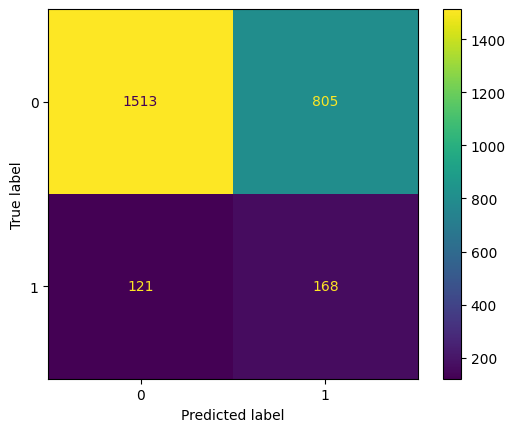

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
import keras
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)


class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# TODO: Manual override of class weights here.
class_weight_dict = {0: 1, 1: 7}
print(class_weight_dict)

model_nn = keras.Sequential([
    keras.layers.Dense(256, activation="relu", input_shape=(x_train.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(64, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(1, activation="sigmoid"),
])

model_nn.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
    ],
)

history = model_nn.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
)

y_prob = model_nn.predict(x_test)
y_pred = (y_prob >= 0.5).astype(int)

{0: 1, 1: 7}
Epoch 1/50


c:\Users\Ed\OneDrive - Imperial College London\Documents\_OR-MSC\Machine Learning in Python\ML-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5402 - auc: 0.5266 - loss: 1.3239 - val_accuracy: 0.7291 - val_auc: 0.5736 - val_loss: 0.5967
Epoch 2/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5699 - auc: 0.5516 - loss: 1.2165 - val_accuracy: 0.4813 - val_auc: 0.5779 - val_loss: 0.6647
Epoch 3/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5676 - auc: 0.5514 - loss: 1.2022 - val_accuracy: 0.6855 - val_auc: 0.5928 - val_loss: 0.6207
Epoch 4/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5798 - auc: 0.5573 - loss: 1.1828 - val_accuracy: 0.5029 - val_auc: 0.6094 - val_loss: 0.6631
Epoch 5/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5877 - auc: 0.5796 - loss: 1.1643 - val_accuracy: 0.6357 - val_auc: 0.6072 - val_loss: 0.6398
Epoch 6/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6129 - auc: 0.5978 - loss: 1.1515 - val_accuracy: 0.8226 - val_auc: 0.6217 - val_loss: 0.5373
Epoch 7/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.37      0.53      2318
           1       0.14      0.80      0.23       289

    accuracy                           0.42      2607
   macro avg       0.54      0.58      0.38      2607
weighted avg       0.85      0.42      0.50      2607

